In [1]:
import sys
sys.path.append("../")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from src.prepare_data import load_and_prepare

In [2]:
df = load_and_prepare("../data/daily_activity_survey_data.xlsx")

X = df.drop(columns=["completed"])
y = df["completed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")

Training rows: 13092
Test rows: 1800


In [3]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {
        "accuracy": round(accuracy, 4),
        "cv_mean": round(cv_scores.mean(), 4),
        "cv_std": round(cv_scores.std(), 4)
    }
    print(f"{name} done.")

Logistic Regression done.
Random Forest done.
Decision Tree done.
K-Nearest Neighbors done.
Support Vector Machine done.


In [4]:
results_df = pd.DataFrame(results).T
results_df.columns = ["Test Accuracy", "CV Mean", "CV Std"]
results_df = results_df.sort_values("CV Mean", ascending=False)
print(results_df)

                        Test Accuracy  CV Mean  CV Std
Random Forest                  1.0000   1.0000  0.0000
Decision Tree                  1.0000   1.0000  0.0000
Logistic Regression            0.9822   0.9875  0.0027
Support Vector Machine         0.9800   0.9860  0.0016
K-Nearest Neighbors            0.8906   0.9471  0.0059


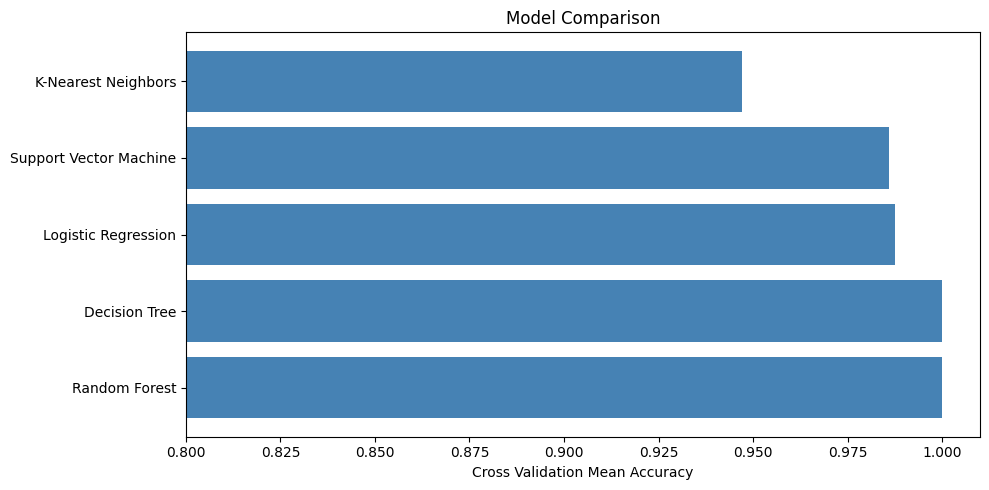

In [5]:
plt.figure(figsize=(10, 5))
x = results_df.index
plt.barh(x, results_df["CV Mean"], color="steelblue")
plt.xlabel("Cross Validation Mean Accuracy")
plt.title("Model Comparison")
plt.xlim(0.8, 1.01)
plt.tight_layout()
plt.show()

In [6]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       148
           1       1.00      0.98      0.99      1652

    accuracy                           0.98      1800
   macro avg       0.91      0.99      0.95      1800
weighted avg       0.99      0.98      0.98      1800


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00      1652

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800


--- Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00      1652

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800

Conclusion

Five models were evaluated using cross validation and test set metrics.

Random forest and Decision tree achieved perfect scores, indicating overfitting.
Logistic Regression was selected as the final model because it demonstrated consistent, honest performance with perfect class 0 recall and low variance across cross validation folds. It is also the most interpretable model for this use case.